In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

import numpy as np
from datetime import datetime

# # # # # # # # # # # # # # #
save = True
fp_type = 'vini'
dist_type = 'euclidean'
# # # # # # # # # # # # # # #

today = datetime.today().strftime('%Y%m%d%H')
    
if dist_type=='euclidean':
    d = 'eucnorm'
    
v = '_'.join(['baseline','2000n_test',fp_type,d])
tag = f'{today}_{v}'
print(tag)

2022050300_baseline_2000n_test_vini_eucnorm


## 1) Get anc-aug map.

In [2]:
rdir = '/home/kat/Repos/SALSA/results/'
mdir = '/home/kat/Repos/SALSA/data/model_ready/'

from eval_functions import *

which_test = '01'
which_train = '01'

anc_path = f'{mdir}{which_test}/test/anchor_smiles.csv'
aug_path = f'{mdir}{which_test}/test/augmented_smiles.csv'   
anc_map = get_anc_map( get_dataset_array(anc_path, aug_path) )

## 2) Load model UMAP for consistent ordering of coords (?)

In [3]:
# Which evaluation set? ...
# # # # # # # # # # # 
umap_tag = '2022041809_a04_2000n_test_32neigh_mindist0pt1'
# # # # # # # # # # # 

import pandas as pd
from utilities.fp_utils import get_fps_in_parallel
import numpy as np
from rdkit.Chem import PandasTools
from sklearn import preprocessing

df = pd.read_csv(f'{rdir}umap_dfs/{umap_tag}.csv', usecols=["Smiles","Label","Atype"])
PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
# display(df)

## 3) Calculate Vini descriptors.

In [4]:
from joblib import Parallel, delayed
from cheminformatics import calc_rdkit

def get_vini_feats_in_parallel(mols):
    parallelizer = Parallel(n_jobs=-1, backend= 'multiprocessing' )
    fp_tasks = (delayed(calc_rdkit)(mol) for mol in mols)
    fps = parallelizer(fp_tasks)
    fps = np.vstack(fps)
    return fps

fps = get_vini_feats_in_parallel(df.Mol)
fps = np.stack(fps)
print(fps.shape)

(12000, 188)


In [5]:
nan_idc = np.argwhere(fps!=fps)
nan_set = np.unique(nan_idc[:,1])
print(nan_set)
idc_clean = [i for i in np.arange(fps.shape[1]) if i not in nan_set]
fps_clean = fps[:,idc_clean]
print(fps_clean.shape)

[ 7  8  9 10]
(12000, 184)


In [6]:
if dist_type=='euclidean':
    fps_clean = preprocessing.normalize(fps_clean, norm='l2', axis=1)
print(fps_clean.shape)

(12000, 184)


## 3) Get distances. Save file.

In [7]:
from tqdm.notebook import tqdm
from scipy.spatial import distance
from itertools import combinations as combo

anc_aug_dists = []
far = []
for anc,augs in tqdm(anc_map.items(), total=len(anc_map)):
    augs = list(augs)
    augs.pop(0)
    
    fp_anc = fps_clean[anc]    
    for aug in augs:
        fp_aug = fps_clean[aug]
        
        if dist_type=='tanimoto':
            d = distance.rogerstanimoto(fp_anc, fp_aug)
        elif dist_type=='jaccard':
            d = distance.jaccard(fp_anc, fp_aug)
        elif dist_type=='euclidean':
            d = distance.euclidean(fp_anc, fp_aug)
            
        if d > 1:
            far.append(anc)
        anc_aug_dists.append(d)
        
dist_arr = np.array(anc_aug_dists)        
if save:
    txt_out = f'{rdir}anc_aug_dists/{tag}.txt'
    np.savetxt(txt_out, dist_arr)

  0%|          | 0/2000 [00:00<?, ?it/s]

## 4) Plot histogram.

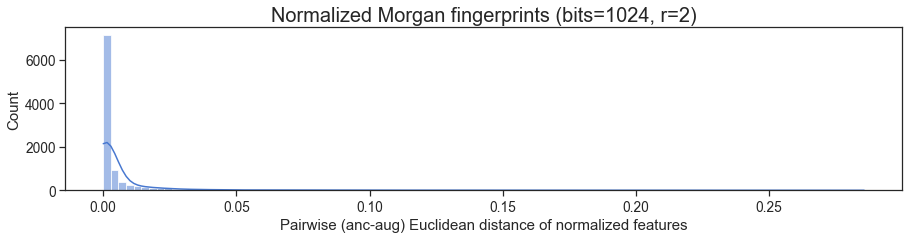

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

bns = 100
ylim = 750

t = f'Normalized Morgan fingerprints (bits=1024, r=2)' #, {bns} bins)'

plt.figure(figsize=(15,3))
plt.title(t,fontsize=20)
# plt.ylim(0,ylim)
# plt.xlim(0,1.5)

sns.histplot(anc_aug_dists, kde=True, bins=bns) #bins=100)

if dist_type=='tanimoto':
    plt.xlabel('Pairwise (anc-aug) Tanimoto distance of descriptors')
elif dist_type=='jaccard':
    plt.xlabel('Pairwise (anc-aug) Jaccard distance of descriptors')
elif dist_type=='euclidean':
    plt.xlabel('Pairwise (anc-aug) Euclidean distance of normalized features')
    
plt.savefig(f'{rdir}plot_figs/{tag}_{bns}bins_ylim{ylim}.png', bbox_inches='tight')
plt.show()

## 5) Calculate and plot UMAP projection.

In [9]:
import umap.umap_ as umap
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import random

def get_umap_coords(tag_emb, df, latents, n_neighs, min_dist, 
                    save_coords=True, save_plot=True, show_plot=True):
 
    rdir = '/home/kat/Repos/SALSA/results/'
    
    pt = str(min_dist).split('.')[1]
    tag_coords = '_'.join([tag_emb, f'{n_neighs}neigh', f'mindist0pt{pt}'])
    print(f"Tag is {tag_coords}!")
    
    umapper = umap.UMAP(n_neighbors=n_neighs, min_dist=min_dist, 
                        n_components=2, metric='euclidean')
    embedding = umapper.fit_transform(latents)

    df['x'] = embedding[:, 0]
    df['y'] = embedding[:, 1]

    if save_coords:
        csv_out = f'{rdir}umap_dfs/{tag_coords}.csv'
        df.to_csv(csv_out,index=False)
        print(f"Saved smiles and coords to {csv_out}!")
        
    sns.set_theme(style='ticks',font_scale=1.5)
    plt.figure(figsize=(10,10))
    sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                    alpha=0.5, s=10, palette={'Aug':'red'})
    sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                    alpha=1., s=7, palette={'Anc':'blue'})
        
    if save_plot:
        png_out = f'{rdir}umap_figs/{tag_coords}.png'
        plt.savefig(png_out, bbox_inches='tight')
        print(f"Saved umap plot to {png_out}!")
    if show_plot:
        plt.show()
        
    return df

Tag is 2022050300_baseline_2000n_test_vini_eucnorm_32neigh_mindist0pt1!


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022050300_baseline_2000n_test_vini_eucnorm_32neigh_mindist0pt1.csv!
Saved umap plot to /home/kat/Repos/SALSA/results/umap_figs/2022050300_baseline_2000n_test_vini_eucnorm_32neigh_mindist0pt1.png!


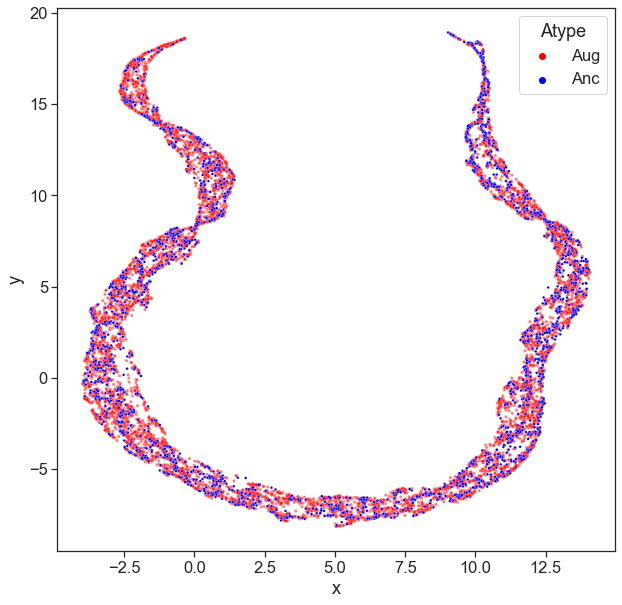

,Smiles,Atype,Label,Mol,x,y
0,CC(C)CC(NC(=O)C(CC(C)C)NC(=O)C1NC(=O)NC(=O)C1F...,Anc,0,,0.501938,-4.881587
1,O=C(Nc1cccc(C(F)(F)F)c1)c1nscc1NCCc1ccc2c(c1)OCO2,Anc,1,,-1.676167,14.389578
2,c1ccc(-c2nnc(N3CCOCC3)c3ccccc23)cc1,Anc,2,,9.316841,-6.412125
3,NC1(C(=O)O)CCc2cc(N(CCCl)CCCl)ccc2C1,Anc,3,,12.738104,4.371993
4,Cc1ncoc1-c1nnc(SCCCNC2CC3CC3(c3ccccc3)C2)n1C,Anc,4,,-1.109039,13.640708
...,...,...,...,...,...,...
11995,CC(Cn1nnc2ccccc2c1=O)C(=O)NCC1CCC(C(=O)O)CC1,Aug,1999,,-3.053640,-0.787109
11996,Cc1ccc2c(=O)n(CCC(=O)NCC3CCC(C(=O)O)CC3)nnc2c1,Aug,1999,,-2.857476,-1.584759
11997,NC1(CNC(=O)CCn2nnc3ccccc3c2=O)CCC(C(=O)O)CC1,Aug,1999,,-2.688004,-1.978797
11998,CC(NC(=O)CCn1nnc2ccccc2c1=O)C1CCC(C(=O)O)CC1,Aug,1999,,-2.977108,-0.883836

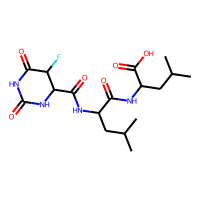
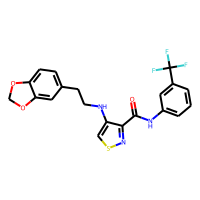
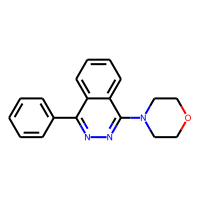
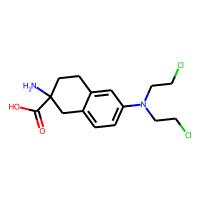
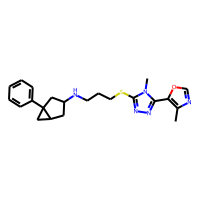
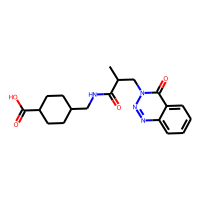
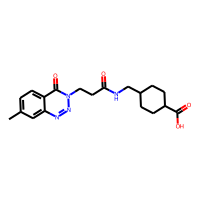
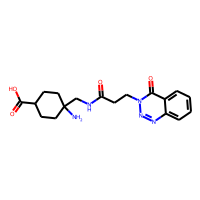
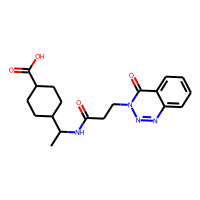
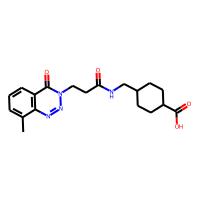

In [10]:
get_umap_coords(tag_emb=tag, df=df, latents=fps_clean, n_neighs=32, min_dist=0.1, 
               save_coords=True, save_plot=True, show_plot=True)